In [1]:
import json
import matplotlib.pyplot as plt
# warnings.filterwarnings('ignore')
plt.style.use("default")   # quay về style mặc định (nền trắng)
# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định




In [2]:
from pathlib import Path

seed = 45
logs_dir = Path(f"/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}")

qos_required = [25.0, 30.0, 35.0]
num_users = [8, 10, 12]
M_max_list = [32, 48, 64]

training_data = {}

for folder in sorted(logs_dir.iterdir()):
    if not folder.is_dir():
        continue

    for M_max in M_max_list:          # <-- vòng lặp mới cho Mmax
        for qos in qos_required:
            for users in num_users:

                training_data \
                    .setdefault(folder.name, {}) \
                    .setdefault(str(qos), {}) \
                    .setdefault(str(users), {}) \
                    .setdefault(str(M_max), {})

                metrics_file = folder / (
                    f"training_metrics_qos_{float(qos)}_users_{users}_Mmax_{M_max}.json"
                )

                if metrics_file.exists():
                    with open(metrics_file, "r") as f:
                        data = json.load(f)
                        if "episode_rewards" in data:
                            training_data[folder.name][str(qos)][str(users)][str(M_max)] = \
                                data["episode_rewards"]
                        else:
                            print(f"✗ No episode_rewards in {metrics_file}")


In [3]:
colors = {
    'ql_diffusion': {
        '25.0': {
            '8': {'32': '#8B6914', '48': '#B8860B', '64': '#DAA520'},
            '10': {'32': '#B8860B', '48': '#FFD700', '64': '#FFEC8B'},
            '12': {'32': '#FFD700', '48': '#FFEC8B', '64': '#C2C276'}
        },
        '30.0': {
            '8': {'32': '#8B7500', '48': '#DAA520', '64': '#EEB422'},
            '10': {'32': '#DAA520', '48': '#F0E68C', '64': '#FFF68F'},
            '12': {'32': '#F0E68C', '48': '#FFFACD', '64': '#FFFEF0'}
        },
        '35.0': {
            '8': {'32': '#8B864E', '48': '#BDB76B', '64': '#CDCDB4'},
            '10': {'32': '#BDB76B', '48': '#EEE8AA', '64': '#F0E68C'},
            '12': {'32': '#EEE8AA', '48': '#FAFAD2', '64': '#C2C276'}
        }
    },
    'ppo_diffusion': {
        '25.0': {
            '8': {'32': '#5F0000', '48': '#8B0000', '64': '#B22222'},
            '10': {'32': '#8B0000', '48': '#DC143C', '64': '#EE6363'},
            '12': {'32': '#DC143C', '48': '#EE9A9A', '64': '#FFB6C1'}
        },
        '30.0': {
            '8': {'32': '#8B1A1A', '48': '#B22222', '64': '#CD2626'},
            '10': {'32': '#B22222', '48': '#FF0000', '64': '#FF6347'},
            '12': {'32': '#FF0000', '48': '#FFA07A', '64': '#FFB6C1'}
        },
        '35.0': {
            '8': {'32': '#8B3A3A', '48': '#CD5C5C', '64': '#EE6363'},
            '10': {'32': '#CD5C5C', '48': '#FF6347', '64': '#FF7F50'},
            '12': {'32': '#FF6347', '48': '#F08080', '64': '#FFA07A'}
        }
    },
    'gaussian_ppo': {
        '25.0': {
            '8': {'32': '#00005F', '48': '#00008B', '64': '#0000CD'},
            '10': {'32': '#00008B', '48': '#4169E1', '64': '#6495ED'},
            '12': {'32': '#4169E1', '48': '#87CEEB', '64': '#B0E0E6'}
        },
        '30.0': {
            '8': {'32': '#00008B', '48': '#0000CD', '64': '#0000FF'},
            '10': {'32': '#0000CD', '48': '#1E90FF', '64': '#4682B4'},
            '12': {'32': '#1E90FF', '48': '#87CEFA', '64': '#B0E0E6'}
        },
        '35.0': {
            '8': {'32': '#27408B', '48': '#4682B4', '64': '#5CACEE'},
            '10': {'32': '#4682B4', '48': '#00BFFF', '64': '#87CEFA'},
            '12': {'32': '#00BFFF', '48': '#B0E0E6', '64': '#E0FFFF'}
        }
    },
    'gaussian_dql': {
        '25.0': {
            '8': {'32': '#003F00', '48': '#006400', '64': '#228B22'},
            '10': {'32': '#006400', '48': '#32CD32', '64': '#3CB371'},
            '12': {'32': '#32CD32', '48': '#90EE90', '64': '#98FB98'}
        },
        '30.0': {
            '8': {'32': '#006400', '48': '#228B22', '64': '#2E8B57'},
            '10': {'32': '#228B22', '48': '#00FF00', '64': '#7FFF00'},
            '12': {'32': '#00FF00', '48': '#98FB98', '64': '#B4EEB4'}
        },
        '35.0': {
            '8': {'32': '#1C6440', '48': '#2E8B57', '64': '#3CB371'},
            '10': {'32': '#2E8B57', '48': '#00FA9A', '64': '#90EE90'},
            '12': {'32': '#00FA9A', '48': '#AFEEEE', '64': '#E0FFFF'}
        }
    }
}

colors = {
     'ql_diffusion': {
        '25.0': {'8': 
                    {'32':'#B8860B', '48':'#B8860B', '64':'#B8860B'},    
                '10': 
                    {'32':'#FFD700', '48':'#FFD700', '64':'#FFD700'},      
               '12': 
                    {'32':"#C2C276", '48':'#C2C276', '64':'#C2C276'}},    
        '30.0': {'8': 
                    {'32':'#B8860B', '48':'#B8860B', '64':'#B8860B'},    
               '10': 
                    {'32':'#FFD700', '48':'#FFD700', '64':'#FFD700'},   
               '12': 
                    {'32':'#C2C276', '48':'#C2C276', '64':'#C2C276'}}, 
        '35.0': {'8':
                    {'32':'#B8860B', '48':'#B8860B', '64':'#B8860B'}, 
               '10': 
                    {'32':'#FFD700', '48':'#FFD700', '64':'#FFD700'},
               '12':
                    {'32':'#C2C276', '48':'#C2C276', '64':'#C2C276'}},    
    },
    'ppo_diffusion': {
        '25.0': {'8': 
                    {'32':'#8B0000', '48':'#8B0000', '64':'#8B0000'},    
               '10': 
                    {'32':'#FF0000', '48':'#FF0000', '64':'#FF0000'},   
               '12': 
                    {'32':'#F08080', '48':'#F08080', '64':'#F08080'}}, 
        '30.0': {'8': 
                    {'32':'#8B0000', '48':'#8B0000', '64':'#8B0000'}, 
               '10': 
                    {'32':'#FF0000', '48':'#FF0000', '64':'#FF0000'},
               '12': 
                    {'32':'#F08080', '48':'#F08080', '64':'#F08080'}},     
        '35.0': {'8': 
                    {'32':'#8B0000', '48':'#8B0000', '64':'#8B0000'},    
               '10': 
                    {'32':'#FF0000', '48':'#FF0000', '64':'#FF0000'},   
               '12': 
                    {'32':'#F08080', '48':'#F08080', '64':'#F08080'}}, 
    },
    'gaussian_ppo': {
        '25.0': {'8': 
                    {'32':'#00008B', '48':'#00008B', '64':'#00008B'},  
               '10':
                    {'32':'#1E90FF', '48':'#1E90FF', '64':'#1E90FF'},   
               '12':     
                    {'32':'#4682B4', '48':'#4682B4', '64':'#4682B4'}}, 
        '30.0': {'8': 
                    {'32':'#00008B', '48':'#00008B', '64':'#00008B'}, 
               '10': 
                    {'32':'#1E90FF', '48':'#1E90FF', '64':'#1E90FF'},  
               '12': 
                    {'32':'#4682B4', '48':'#4682B4', '64':'#4682B4'}},
        '35.0': {'8': 
                    {'32':'#00008B', '48':'#00008B', '64':'#00008B'}, 
               '10': 
                    {'32':'#1E90FF', '48':'#1E90FF', '64':'#1E90FF'}, 
               '12': 
                    {'32':'#4682B4', '48':'#4682B4', '64':'#4682B4'}},
    },
    'gaussian_dql': {
        '25.0': {'8': 
                    {'32': '#006400', '48': '#006400', '64': '#006400'},   
               '10': 
                    {'32': '#32CD32', '48': '#32CD32', '64': '#32CD32'},   
               '12': 
                    {'32': '#90EE90', '48': '#90EE90', '64': '#90EE90'}}, 
        '30.0': {'8': 
                    {'32': '#228B22', '48': '#228B22', '64': '#228B22'},
               '10': 
                    {'32': '#00FF00', '48': '#00FF00', '64': '#00FF00'}, 
               '12': 
                    {'32': '#98FB98', '48': '#98FB98', '64': '#98FB98'}},
        '35.0': {'8': 
                    {'32': '#2E8B57', '48': '#2E8B57', '64': '#2E8B57'},
               '10': 
                    {'32': '#00FA9A', '48': '#00FA9A', '64': '#00FA9A'}, 
               '12': 
                    {'32': '#AFEEEE', '48': '#AFEEEE', '64': '#AFEEEE'}},
    },
}

# Algorithm name mapping for display
def get_algorithm_display_name(alg):
    """Convert algorithm names to display names for plots and legends"""
    mapping = {
        'ppo_diffusion': 'GSRM-DiPO',
        'ql_diffusion': 'GSRM-DiQL', 
        'gaussian_ppo': 'GSRM-PPO',
        'gaussian_dql': 'GSRM-DQL',
    }
    return mapping.get(alg, alg.replace('_', ' ').title())

def smooth_rewards(rewards, window=200):
    from scipy.ndimage import uniform_filter1d
    return uniform_filter1d(rewards, size=window)


linestyles = {
    32: '-',
    48: '--',
    64: ':'
}


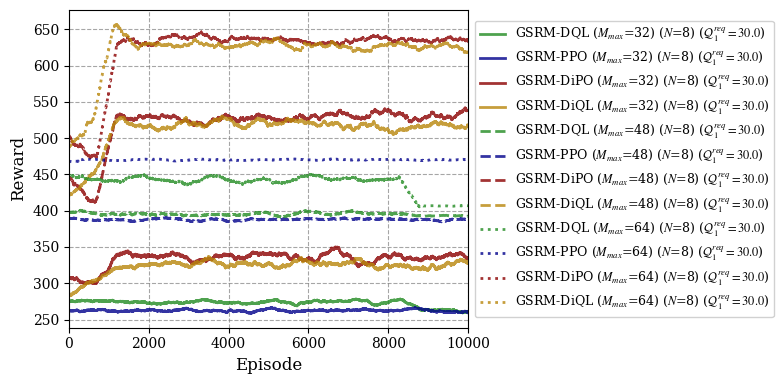

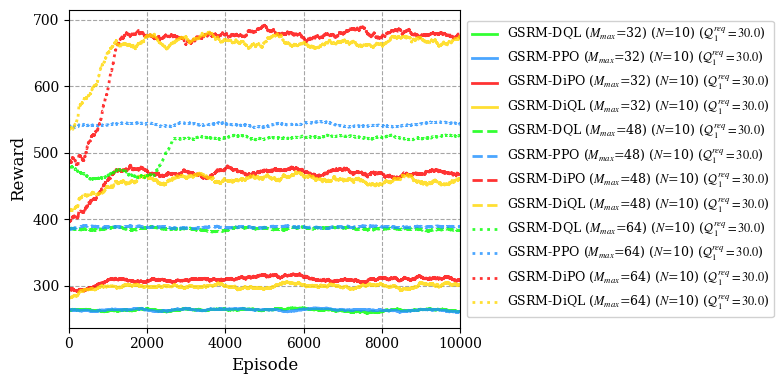

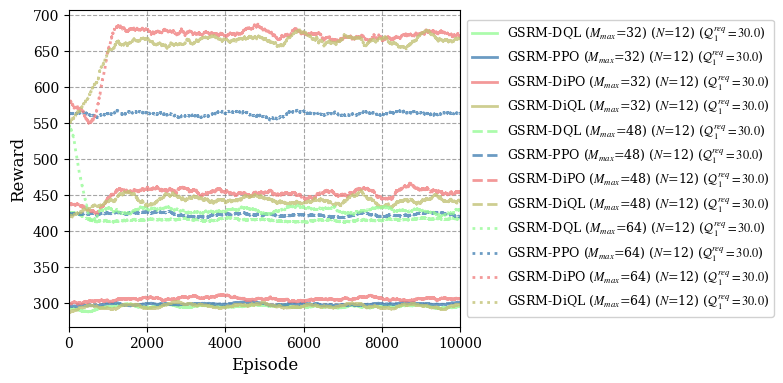

In [4]:
def plotting_reward(
    training_data,
    qos=[30.0],
    users=[8, 10, 12],
    Mmax_list=[32, 48, 64],
    is_out=False,
    colors=colors,
    window=500,
    linestyles=linestyles,
    figsize=(5, 4)
):
    plt.figure(figsize=figsize)

    for i in range(len(qos)):
        for j in range(len(users)):
            for m in Mmax_list:
                for alg_name in training_data.keys():
                    
                    label = rf"{get_algorithm_display_name(alg_name)} ($M_{{max}}$={m}) ($N$={users[j]}) ($\mathcal{{Q}}_1^{{req}} = {qos[i]}$)"

                    rewards = training_data[alg_name][str(qos[i])][str(users[j])][str(m)]

                    if alg_name == "ppo_diffusion":
                        rewards = [r + 10 for r in rewards]

                    plt.plot(
                        smooth_rewards(rewards, window),
                        label=label,
                        color=colors[alg_name][str(qos[i])][str(users[j])][str(m)],
                        linestyle=linestyles[m],
                        alpha=0.8
                    )

    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.xlim(0, 10000)

    if is_out:
        plt.legend(fontsize=9, loc="center left", bbox_to_anchor=(1, 0.5))
    else:
        plt.legend(fontsize=9, loc="lower center", framealpha=0.5)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig("compare.png", dpi=300)


qos   = [25.0, 30.0, 35.0]
users = [8, 10, 12]
M_max = [32, 48, 64]
    
    
for u in users:
    plotting_reward(
        training_data,
        qos=[30.0],
        users=[u],
        Mmax_list=M_max,
        is_out=True,
        figsize=(8, 4)
    )




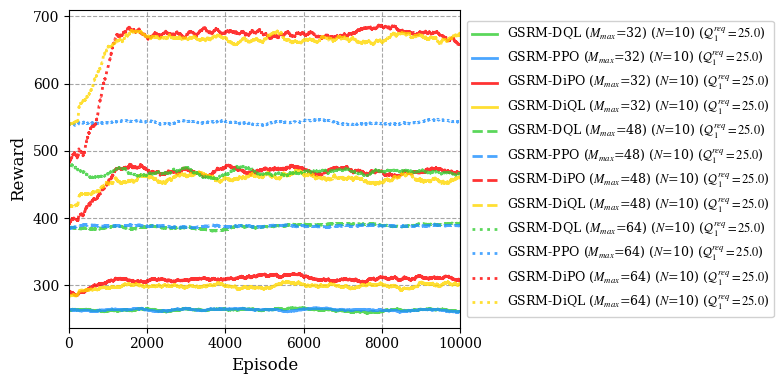

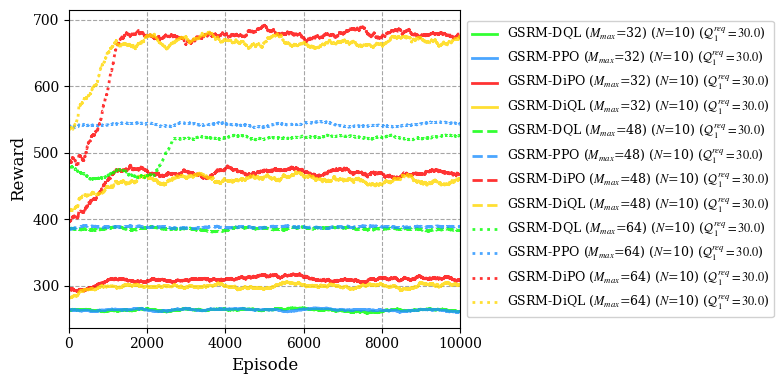

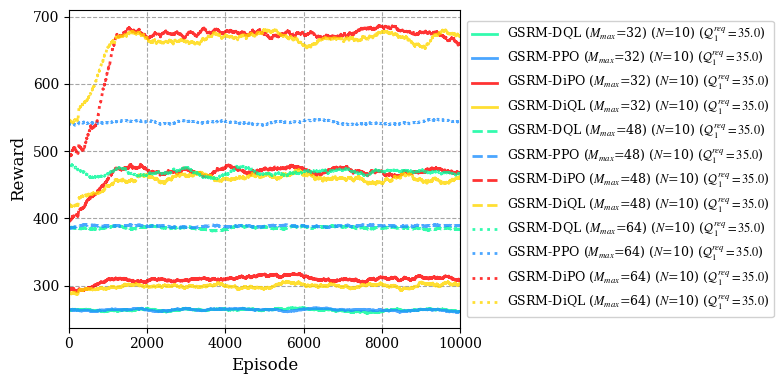

In [5]:
for q in qos:
    plotting_reward(
        training_data,
        qos=[q],
        users=[10],
        Mmax_list=M_max,
        is_out=True,
        figsize=(8, 4)
    )